# The Leaky Integrate-and-Fire Neuron

In [1]:
%matplotlib widget

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

The Leaky Integrate-and-Fire (LIF) Neuron model is a fundamental mathematical representation of a biological neuron. It models a neuron's membrane potential as an electrical circuit that adds up incoming input while continuously leaking charge. If the neuron accumulates enough charge to hit some spiking threshold, it emits a spike and resets its membrane potential. The dynamics of the LIF neuron are given by
$$
C \dot\mu = \frac{\mu^0 - \mu(t)}{R} + I(t).
$$
The goal in this notebook is to use first principles to re-construct this equation.

An LIF neuron essentially does two things: it accumulates input over time, and it leaks its charge. To start, let's introduce some of the components of an LIF neuron. 

Let $\mu(t)$ denote the membrane potential at time $t$. This represents charge accumulated across the cell membrane and measures how "close" a neuron is to firing.

Two forces act on $\mu(t)$ at every instant:

1. Leak: accumulated charge will "leak" out of the neuron since the membrane is not perfectly insulated. The rate of leak is determined by how far the current membrane potential is from an equilibrium resting potential. Let $\mu^0$ represent this membrane resting potential.
2. Inputs: incoming signals from other neurons or an external stimulus push the membrane potential toward the spiking threshold. The inputs feeding into the LIF neuron can be described with a time-indexed function, $I(t)$.

Armed with these three pieces, $\mu(t)$, $\mu^0$, and $I(t)$, we can define the fundamental core of an LIF neuron.

## LIF Fundamentals: Leak and Input

Using three pieces, we can define a basic differential equation that captures leak and input dynamics of the LIF neuron:
$$
\dot\mu = \mu^0 - \mu(t) + I(t),
$$
where $\dot\mu$ is the temporal derivative of the membrane potential $\mu(t)$. This equation posits that the change in membrane potential is dependent on a leak component and an input component, shown in red and green, respectively.
$$
\dot\mu = \color{red}{\mu^0 - \mu(t)} \color{white}+ \color{green}{I(t)}
$$

### Leak Demonstration

For now, let's consider the case where no input is being supplied to the neuron. That is, $I(t) = 0$ for all time steps $t$. In this case, the temporal derivative of $\mu(t)$ depends only on the leak term:
$$
\dot\mu = \mu^0 - \mu(t).
$$

This captures the biophysical behavior of real neurons. The resting potential of a biological neuron is an electrochemical equilibrium between the ions inside of the cell and the ions outside of the cell. The neuron's membrane potential wants to be in equilibrium, so any deviation from the resting potential faces a restoring force that tries to bring the membrane potential back to rest.

The equation above reinforces $\mu^0$'s role as the membranes resting potential. If $\mu(t)$ is less than $\mu^0$, then $\dot\mu$ is positive and the membrane potential is increasing (toward $\mu^0$). If $\mu(t)$ is greater than $\mu^0$, then $\dot\mu$ is negative and the membrane potential is decreasing (still toward $\mu^0$). And if $\mu(t) = \mu^0$, then $\dot\mu = 0$ and the membrane potential is happy where it is; it does not change.

Let's simulate these leaky dynamics. First, we will define some parameters.

In [3]:
# LIF Parameters
t_max = 10 # 10 s of recording time
dt = 0.01 # 10 ms timesteps
mu_0 = -60 # -60 mV resting potential
step_end = int(t_max / dt) # Number of total timesteps

As a brief aside, in order to simulate the membrane voltage in discrete time, we use discrete time integration. This amounts to calculating the temporal derivative at each time step and nudging the membrane potential in that direction by a little amount. For small enough time steps ($dt \to 0$), then
$$
\mu(t + dt) = \mu(t) + \dot\mu \:dt
$$

For our purposes, we use `dt = 0.01`.


Let's start by setting the initial membrane potential above the resting potential, so $\mu(0) > \mu^0$. We'll see how the membrane potential converges to the resting potential.

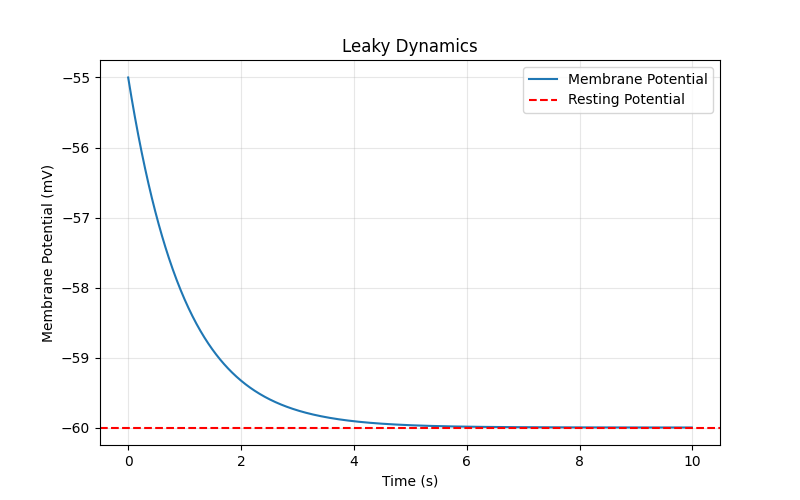

In [4]:
# Intitialize membrane potential
mu = np.zeros(step_end)
mu[0] = -55 # -55 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1]) * dt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Leaky Dynamics")
ax.legend(); ax.grid(alpha=0.3)

plt.show()

So with no external input, any membrane potential above the resting potential eventually falls to the resting potential.

Likewise, any membrane potential below the resting potential will eventually rise to the resting potential.

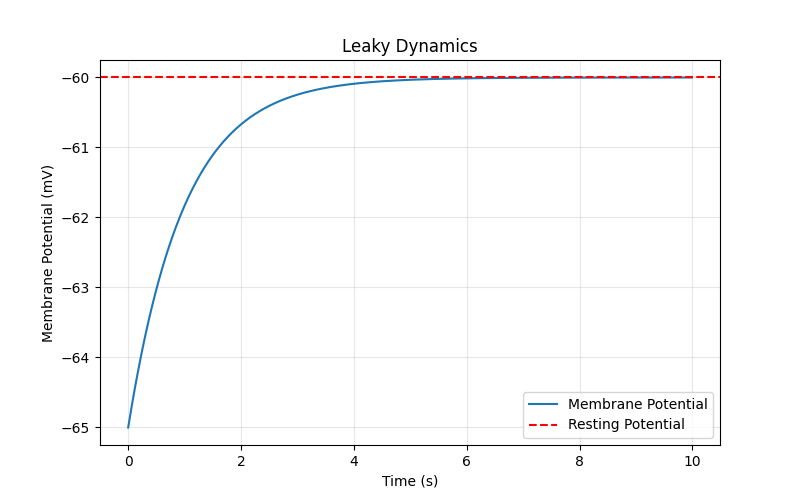

In [5]:
# Intitialize membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1]) * dt

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Leaky Dynamics")
ax.legend(); ax.grid(alpha=0.3)

plt.show()

#### Interactive Demo

This demo allows you to choose the initial value of the membrane potential, $\mu(0)$, as well as the resting potential value $\mu^0$ and watch the membrane potential evolve over time.

FloatSlider(value=-65.0, description='Initial membrane potential:', max=-45.0, min=-75.0, step=1.0)

FloatSlider(value=-60.0, description='Resting potential:', max=-45.0, min=-75.0, step=1.0)

IntSlider(value=0, description='Time:', max=1000)

Play(value=0, interval=5, max=1000)

Output()

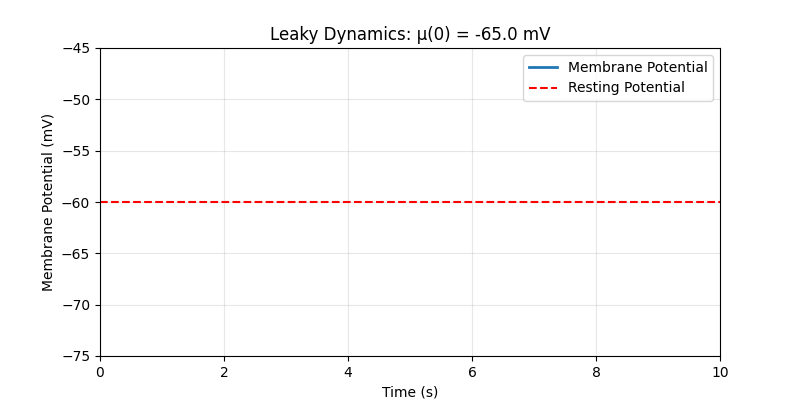

In [6]:
# Interactive Widget
time = np.arange(0, t_max + dt, dt)

# Runs leaky dynamics simulation
def simulate(mu_init, mu_0):
    mu = np.empty(len(time))
    mu[0] = mu_init
    for i in range(1, len(time)):
        mu[i] = mu[i-1] + (mu_0 - mu[i-1]) * dt
    return mu

fig, ax = plt.subplots(figsize=(8, 4))

def plot_dynamics(mu_init, mu_0, t_idx):
    mu = simulate(mu_init, mu_0)
    ax.clear()
    ax.plot(time[:t_idx + 1], mu[:t_idx + 1], lw=2, label="Membrane Potential")
    ax.axhline(mu_0, color="red", ls="--", label="Resting Potential")
    ax.set_xlim(0, t_max); ax.set_ylim(-75, -45)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Membrane Potential (mV)")
    ax.set_title(f"Leaky Dynamics: μ(0) = {mu_init:.1f} mV")
    ax.legend(); ax.grid(alpha=0.3)
    fig.canvas.draw_idle()

mu_slider = widgets.FloatSlider(value=-65, min=-75, max=-45, step=1, description="Initial membrane potential:")
time_slider = widgets.IntSlider(value=0, min=0, max=len(time) - 1, description="Time:")
mu_0_slider = widgets.FloatSlider(value=-60, min=-75, max=-45, step=1, description="Resting potential:")
play = widgets.Play(value=0, min=0, max=len(time) - 1, interval=5)
widgets.jslink((play, "value"), (time_slider, "value"))

def reset_time(change):
    play.playing = False
    play.value = 0
    time_slider.value = 0

mu_slider.observe(reset_time, names="value")
mu_0_slider.observe(reset_time, names="value")

out = widgets.interactive_output(plot_dynamics, {"mu_init": mu_slider, "mu_0": mu_0_slider, "t_idx": time_slider})
display(mu_slider, mu_0_slider, time_slider, play, out)

### Input Demonstration

We've seen that the leak dynamics above depend on the value of the equilibrium resting potential. Now let's see how the membrane dynamics respond to external inputs.

Reintroducing the input $I(t)$, the dynamics of the LIF neuron's membrane potential is given by
$$
\dot\mu = \mu^0 - \mu(t) + \color{green}{I(t)}.
$$
For the purposes of this demonstration, let's assume $I(t)$ 

## Capacitance and Resistance